# GridSearchCV - Random Forest for Mobile Price Classification

This notebook performs the required hyperparameter tuning using 5-fold GridSearchCV and saves the best model for the Streamlit app.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [2]:
# Load the Kaggle dataset
try:
    df = pd.read_csv("train.csv")
except FileNotFoundError:
    import kagglehub
    dataset_path = kagglehub.dataset_download("iabhishekofficial/mobile-price-classification")
    df = pd.read_csv(os.path.join(dataset_path, "train.csv"))

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2000, 21)


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [3]:
X = df.drop("price_range", axis=1)
y = df["price_range"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(1600, 20) (400, 20)


## GridSearchCV

In [4]:
rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)
print("\nBest Cross-Validation Score:")
print(grid.best_score_)

Best Parameters:
{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross-Validation Score:
0.871875


## Test Set Evaluation

Test Accuracy: 0.8825

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       100
           1       0.83      0.85      0.84       100
           2       0.83      0.78      0.80       100
           3       0.92      0.94      0.93       100

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.88       400
weighted avg       0.88      0.88      0.88       400



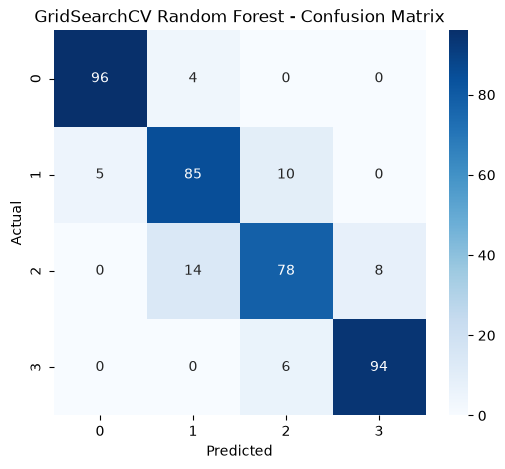

In [5]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("GridSearchCV Random Forest - Confusion Matrix")
plt.show()

## Save the Tuned Model

In [6]:
joblib.dump(best_model, "best_mobile_price_model.pkl")
print("Saved: best_mobile_price_model.pkl")

Saved: best_mobile_price_model.pkl


## Conclusion

GridSearchCV tests different Random Forest hyperparameter combinations using 5-fold cross-validation. The best parameters and cross-validation score are printed above. The final tuned model is saved for the Streamlit application.